# RFscorer 実践チュートリアル (日本語)

このノートブックでは `rfscorer` の実践的な利用方法を説明します。

Google Colab で利用する場合、次の準備が必要になります。

- `rfscorer`のインストール
```python
!pip install rfscorer
```

- Googleドライブのマウント（ファイルの入出力をする場合）
```python
from google.colab import drive
drive.mount("/content/drive")
```

---
## **データ取得と前処理**

In [1]:
import pandas as pd

from rfscorer import RecencyFrequencyScorer, split_by_date

In [2]:
# `access_log.csv` は ohmsha/PyOptBook (MIT License)
# https://github.com/ohmsha/PyOptBook/tree/main/7.recommendation
# (MIT License)
url = "https://raw.githubusercontent.com/ohmsha/PyOptBook/main/7.recommendation/access_log.csv"
df = pd.read_csv(url)
df.columns = ["user", "item", "datetime"]

print("record num:", len(df))
print("user num:", len(df.user.unique()))
print("item num:", len(df.item.unique()))
print("datetime num:", len(sorted(df.datetime.unique())))
print("datetime:", sorted(df.datetime.unique()))
df.head()

record num: 325908
user num: 31443
item num: 87611
datetime num: 8
datetime: ['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08']


,user,item,datetime
0,4,205587,2015-07-04
1,4,748683,2015-07-04
2,4,790055,2015-07-04
3,4,790055,2015-07-04
4,4,764638,2015-07-04


In [3]:
# 訓練データとテストデータへの分割
df_train = df[df.user.map(lambda x: hash(x) % 10 < 8)]
df_test = df[df.user.map(lambda x: hash(x) % 10 >= 8)]

print("train record num:", len(df_train), "/ user num:", len(df_train.user.unique()))
print("test  record num: ", len(df_test), "/ user num: ", len(df_test.user.unique()))

train record num: 264272 / user num: 25316
test  record num:  61636 / user num:  6127


In [4]:
# 訓練データとテストデータを観測データと正解データへ分割
# 観測期間（target_date 以前 7 日）と正解期間（target_date 翌日以降 1 日）に分割
target_date = "2015-07-07"
df_train_obs, df_train_gt = split_by_date(df_train, target_date, observation_days=7, gt_days=1)
df_test_obs, df_test_gt = split_by_date(df_test, target_date, observation_days=7, gt_days=1)

print("--- train ---")
print("obs/datetime num:", len(sorted(df_train_obs.datetime.unique())))
print("obs/datetime:", sorted(df_train_obs.datetime.unique()))
print("gt/datetime num:", len(sorted(df_train_gt.datetime.unique())))
print("gt/datetime:", sorted(df_train_gt.datetime.unique()))

print("--- test ---")
print("obs/datetime num:", len(sorted(df_test_obs.datetime.unique())))
print("obs/datetime:", sorted(df_test_obs.datetime.unique()))
print("gt/datetime num:", len(sorted(df_test_gt.datetime.unique())))
print("gt/datetime:", sorted(df_test_gt.datetime.unique()))

--- train ---
obs/datetime num: 7
obs/datetime: ['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07']
gt/datetime num: 1
gt/datetime: ['2015-07-08']
--- test ---
obs/datetime num: 7
obs/datetime: ['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07']
gt/datetime num: 1
gt/datetime: ['2015-07-08']


---
## **モデル構築と可視化**

In [5]:
# RFスコアラーのインスタンス作成
scorer = RecencyFrequencyScorer()

In [6]:
# empirical model
# scorer.fit(df_train_obs, df_train_gt)
scorer.fit(df_train_obs, df_train_gt, ref=target_date, recency_limit=7, frequency_limit=15)

scorer.show()

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  rows (obs + gt)  : 264272  (obs: 232157,  gt: 32115)
  observation      : 2015-07-01 → 2015-07-07
  user×item pairs  : 165833 → 165747  (before → after applying limits)
  target events    : 1783 → 1771  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_limit    : 7
  frequency_limit  : 15

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=7,  weighted ρ: -1.0000)
  frequency ρ      :  0.9500  (p=0.0000,  n=15,  weighted ρ:  0.9914)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r=1: 0.9535    r=2: 0.9087    r=3: 0.8785    r=4: 0.7518    r=5: 0.7373    r=6: 0.6899    r=7: 0.5697
  Slice ρ by f  [corr(r, P(r,f)),  expected < 0]
    f=1: -0.8381    f=2: -0.9585    f=3: -0.6543    f=

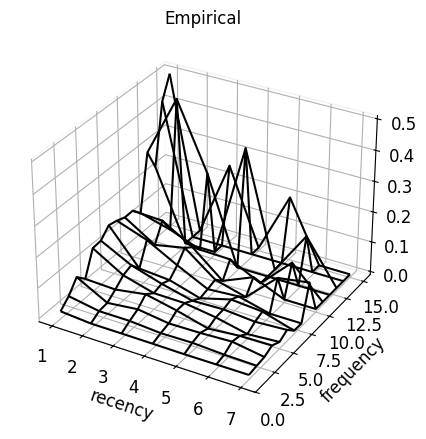

In [7]:
fig_emp = scorer.plot_probability_surface(kind="emp")
fig_emp.savefig("surface_empirical_probability.png")

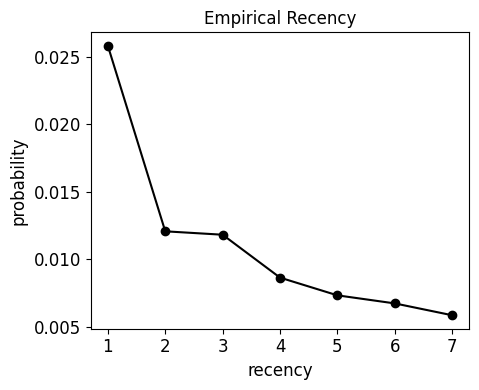

In [8]:
# empirical recency
fig_er = scorer.plot_marginal_probability(kind="er")
fig_er.savefig("marginal_empirical_recency_probability.png")

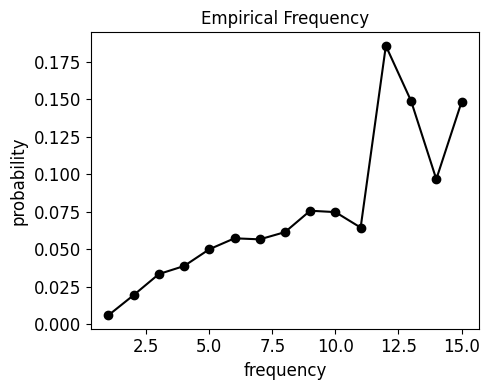

In [9]:
# empirical frequency
fig_ef = scorer.plot_marginal_probability(kind="ef")
fig_ef.savefig("marginal_empirical_frequency_probability.png")

=== show solve info ===
axis: r
eps: 0.0
status: optimal
objective_value: 0.0328
elapsed_time: 0.01[s]
num_variables: 7
num_constraints: 25


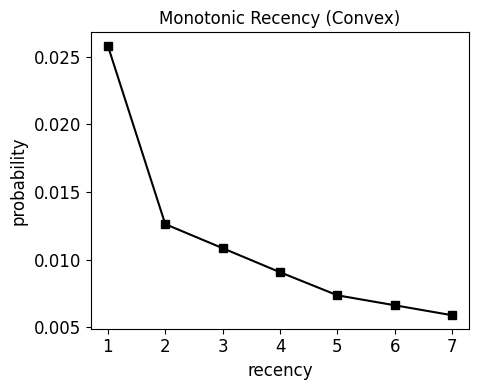

In [10]:
# monotonic recency (convex)
scorer.optimize(kind="mr")
fig_mr = scorer.plot_marginal_probability(kind="mr")
fig_mr.savefig("marginal_monotonic_recency_probability.png")

=== show solve info ===
axis: f
eps: 0.0
status: optimal
objective_value: 0.7680
elapsed_time: 0.01[s]
num_variables: 15
num_constraints: 57


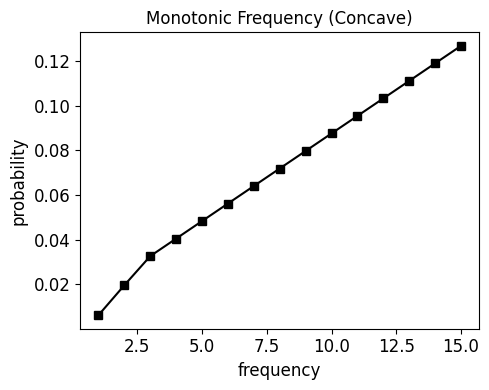

In [11]:
# monotonic frequency (concave)
scorer.optimize(kind="mf")
fig_mf = scorer.plot_marginal_probability(kind="mf")
fig_mf.savefig("marginal_monotonic_frequency_probability.png")

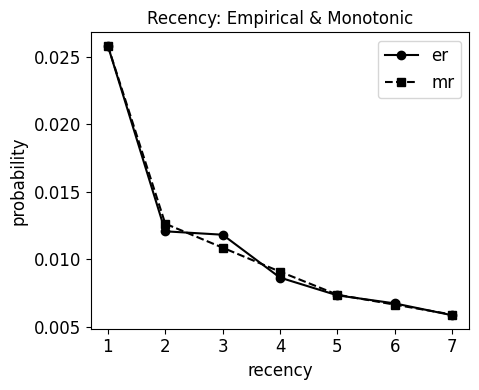

In [12]:
# empirical recency and monotonic recency (convex)
fig_rboth = scorer.plot_marginal_probability(kind="rboth")
fig_rboth.savefig("marginal_recencys_probability.png")

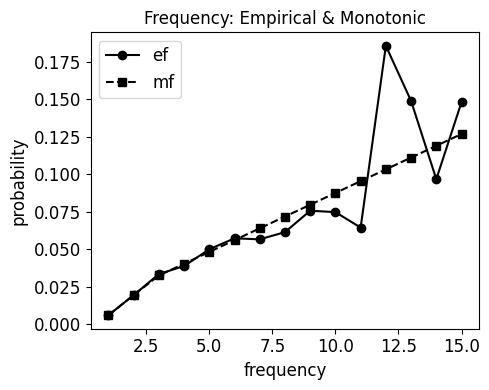

In [13]:
# empirical frequency and monotonic frequency (concave)
fig_fboth = scorer.plot_marginal_probability(kind="fboth")
fig_fboth.savefig("marginal_frequencys_probability.png")

=== show solve info ===
kind: mono
eps: 0.0
status: optimal
objective_value: 3.6409
elapsed_time: 0.12[s]
num_variables: 105
num_constraints: 398


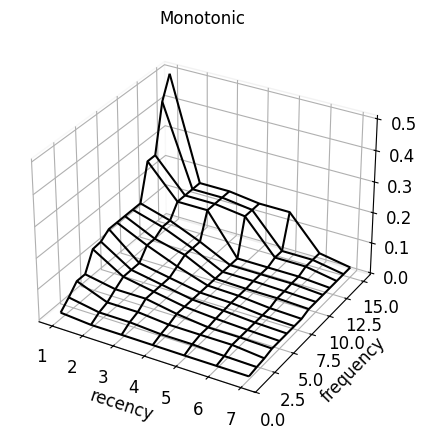

In [14]:
# monotonic model
scorer.optimize(kind="mono")
fig_mono = scorer.plot_probability_surface(kind="mono")
fig_mono.savefig("surface_monotonic_probability.png")

=== show solve info ===
kind: mrc
eps: 0.0
status: optimal
objective_value: 4.1510
elapsed_time: 0.08[s]
num_variables: 105
num_constraints: 473


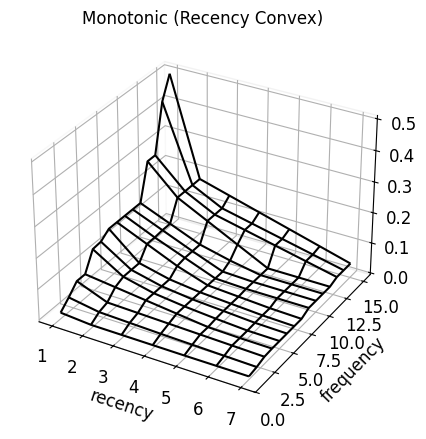

In [15]:
# monotonic & recency convex
scorer.optimize(kind="mrc")
fig_mrc = scorer.plot_probability_surface(kind="mrc")
fig_mrc.savefig("surface_monotonic_recency_convex_probability.png")

=== show solve info ===
kind: mfc
eps: 0.0
status: optimal
objective_value: 5.8416
elapsed_time: 0.11[s]
num_variables: 105
num_constraints: 489


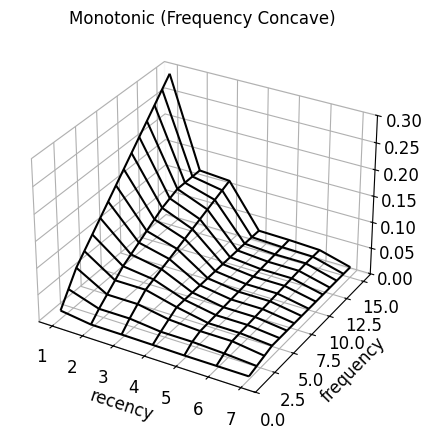

In [16]:
# monotonic & frequency convave
scorer.optimize(kind="mfc")
fig_mfc = scorer.plot_probability_surface(kind="mfc")
fig_mfc.savefig("surface_monotonic_frequency_concave_probability.png")

=== show solve info ===
kind: mcc
eps: 0.0
status: optimal
objective_value: 6.0827
elapsed_time: 0.13[s]
num_variables: 105
num_constraints: 564


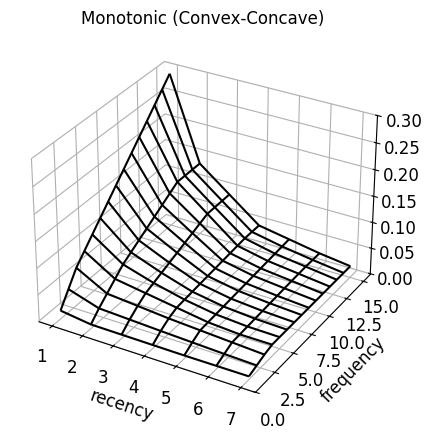

In [17]:
# monotonic recency convex & frequency concave
scorer.optimize(kind="mcc")
scorer.export_probability_csv(kind="mcc")
fig_mcc = scorer.plot_probability_surface(kind="mcc")
fig_mcc.savefig("surface_monotonic_convex_concave_probability.png")

In [18]:
# 全モデルの確率テーブルをひとつの CSV にまとめて出力
scorer.export_probability_csv(kind="all")

kinds = ["er", "ef", "mr", "mf", "emp", "mono", "mrc", "mfc", "mcc"]
for kind in kinds:
    fname = f"prob_{kind}.csv"
    scorer.export_probability_csv(kind=kind, path=fname)

---
## **推薦結果の取得と評価**

In [19]:
# 商品選択確率の予測と推薦順位の付与
kind2df_rec = {kind: scorer.transform(df_test_obs, target_date, kind=kind) for kind in kinds}

In [20]:
# 推薦結果の表示
for kind in kinds:
    print("---", kind, "---")
    display(kind2df_rec[kind].head(3))

--- er ---


,user,item,recency,frequency,probability,order
9190,100099,311656,4,1,0.008624,1
9191,100099,411961,4,1,0.008624,2
9192,100129,353070,5,4,0.007311,1


--- ef ---


,user,item,recency,frequency,probability,order
9190,100099,311656,4,1,0.006062,1
9191,100099,411961,4,1,0.006062,2
9192,100129,353070,5,4,0.038883,1


--- mr ---


...

,user,item,recency,frequency,probability,order
9190,100099,311656,4,1,0.005019,1
9191,100099,411961,4,1,0.005019,2
9192,100129,353070,5,4,0.023603,1


--- mfc ---


,user,item,recency,frequency,probability,order
9190,100099,311656,4,1,0.005122,1
9191,100099,411961,4,1,0.005122,2
9192,100129,353070,5,4,0.023331,1


--- mcc ---


,user,item,recency,frequency,probability,order
9190,100099,311656,4,1,0.005006,1
9191,100099,411961,4,1,0.005006,2
9192,100129,353070,5,4,0.024875,1


In [21]:
# 推薦結果の評価
for kind, df_rec in kind2df_rec.items():
    print("---", kind, "---")
    display(scorer.evaluate(df_rec, df_test_gt, order=3))

--- er ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,5547,84,0.015143,0.014545,0.014838,0.226415,0.028388
1,2,10583,127,0.012000,0.021991,0.015528,0.342318,0.023188
2,3,14336,164,0.011440,0.028398,0.016309,0.442049,0.022302
3,195,38828,371,0.009555,0.064242,0.016636,1.000000,0.018929


--- ef ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,5547,94,0.016946,0.016277,0.016605,0.253369,0.031767
1,2,10583,159,0.015024,0.027532,0.019440,0.428571,0.029030
2,3,14336,196,0.013672,0.033939,0.019492,0.528302,0.026654
3,195,38828,371,0.009555,0.064242,0.016636,1.000000,0.018929


--- mr ---


...

,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,5547,104,0.018749,0.018009,0.018371,0.280323,0.035147
1,2,10583,165,0.015591,0.028571,0.020174,0.444744,0.030126
2,3,14336,207,0.014439,0.035844,0.020586,0.557951,0.028150
3,195,38828,371,0.009555,0.064242,0.016636,1.000000,0.018929


--- mfc ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,5547,103,0.018569,0.017835,0.018195,0.277628,0.034809
1,2,10583,167,0.015780,0.028918,0.020418,0.450135,0.030491
2,3,14336,207,0.014439,0.035844,0.020586,0.557951,0.028150
3,195,38828,371,0.009555,0.064242,0.016636,1.000000,0.018929


--- mcc ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,5547,105,0.018929,0.018182,0.018548,0.283019,0.035485
1,2,10583,167,0.015780,0.028918,0.020418,0.450135,0.030491
2,3,14336,209,0.014579,0.036190,0.020785,0.563342,0.028422
3,195,38828,371,0.009555,0.064242,0.016636,1.000000,0.018929


In [22]:
# 全モデルの precision@1 比較

Rows = []
for kind, df_rec in kind2df_rec.items():
    top = scorer.evaluate(df_rec, df_test_gt, order=1).iloc[0]
    precision = top["precision"]
    recall = top["recall"]
    f1 = top["f1"]
    Rows.append((kind, precision, recall, f1))
df_eval = pd.DataFrame(Rows, columns=["kind", "precision", "recall", "f1"])
df_eval.sort_values("precision", ascending=False)

,kind,precision,recall,f1
8,mcc,0.018929,0.018182,0.018548
6,mrc,0.018749,0.018009,0.018371
7,mfc,0.018569,0.017835,0.018195
5,mono,0.018208,0.017489,0.017841
4,emp,0.017667,0.016970,0.017311
3,mf,0.017126,0.016450,0.016781
1,ef,0.016946,0.016277,0.016605
0,er,0.015143,0.014545,0.014838
2,mr,0.015143,0.014545,0.014838


In [23]:
# 採用モデルの推薦結果を保存
kind2df_rec["mcc"].to_csv("recommendations.csv", index=False)

In [24]:
# モデルの保存
scorer.save("rfscorer.pkl")

In [25]:
# モデルのロード
scorer_loaded = RecencyFrequencyScorer.load("rfscorer.pkl")
scorer_loaded.show()

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  rows (obs + gt)  : 264272  (obs: 232157,  gt: 32115)
  observation      : 2015-07-01 → 2015-07-07
  user×item pairs  : 165833 → 165747  (before → after applying limits)
  target events    : 1783 → 1771  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_limit    : 7
  frequency_limit  : 15

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=7,  weighted ρ: -1.0000)
  frequency ρ      :  0.9500  (p=0.0000,  n=15,  weighted ρ:  0.9914)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r=1: 0.9535    r=2: 0.9087    r=3: 0.8785    r=4: 0.7518    r=5: 0.7373    r=6: 0.6899    r=7: 0.5697
  Slice ρ by f  [corr(r, P(r,f)),  expected < 0]
    f=1: -0.8381    f=2: -0.9585    f=3: -0.6543    f=

---
## **その他の機能**

In [26]:
# 列名が異なるデータへの対応
df_renamed = df.rename(columns={"user": "customer_id", "item": "product_id", "datetime": "date"})
df_train_r = df_renamed[df_renamed.customer_id.map(lambda x: hash(x) % 10 < 8)]
df_test_r = df_renamed[df_renamed.customer_id.map(lambda x: hash(x) % 10 >= 8)]

scorer_r = RecencyFrequencyScorer(user_col="customer_id", item_col="product_id", time_col="date")
df_obs_r, df_gt_r = split_by_date(
    df_train_r, target_date, observation_days=7, gt_days=1, time_col="date"
)
scorer_r.fit(df_obs_r, df_gt_r, ref=target_date, recency_limit=7, frequency_limit=15)

df_test_obs_r, _ = split_by_date(df_test_r, target_date, time_col="date")
scorer_r.optimize(kind="mcc")
scorer_r.transform(df_test_obs_r, target_date, kind="mcc").head()

=== show solve info ===
kind: mcc
eps: 0.0
status: optimal
objective_value: 6.0827
elapsed_time: 0.13[s]
num_variables: 105
num_constraints: 564


,customer_id,product_id,recency,frequency,probability,order
9190,100099,311656,4,1,0.005006,1
9191,100099,411961,4,1,0.005006,2
9192,100129,353070,5,4,0.024875,1
9196,100138,591186,6,4,0.020809,1
9193,100138,852831,6,3,0.019913,2


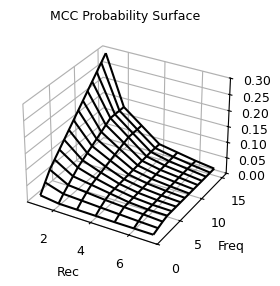

In [27]:
# 3Dグラフの詳細設定の方法の例
fig_mcc = scorer.plot_probability_surface(
    kind="mcc",
    title="MCC Probability Surface",
    figsize=(4, 3),
    fontsize=9,
    recency_label="Rec",
    frequency_label="Freq",
    probability_label="Prob",
)

In [28]:
# 単一の (recency, frequency) ペアに対する商品選択確率の取得
for kind in kinds:
    print(f"  {kind:4s}: {scorer.predict(1, 3, kind=kind):.6f}")

  er  : 0.025795
  ef  : 0.033524
  mr  : 0.025795
  mf  : 0.032568
  emp : 0.081021
  mono: 0.071429
  mrc : 0.071498
  mfc : 0.069306
  mcc : 0.069306


In [29]:
# モデルの zip アーカイブ（確率テーブル・プロット含む）で保存
scorer.save_zip("scorer.zip")

# zip からロード
scorer_loaded_zip = RecencyFrequencyScorer.load_zip("scorer.zip")
scorer_loaded_zip.show()

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  rows (obs + gt)  : 264272  (obs: 232157,  gt: 32115)
  observation      : 2015-07-01 → 2015-07-07
  user×item pairs  : 165833 → 165747  (before → after applying limits)
  target events    : 1783 → 1771  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_limit    : 7
  frequency_limit  : 15

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=7,  weighted ρ: -1.0000)
  frequency ρ      :  0.9500  (p=0.0000,  n=15,  weighted ρ:  0.9914)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r=1: 0.9535    r=2: 0.9087    r=3: 0.8785    r=4: 0.7518    r=5: 0.7373    r=6: 0.6899    r=7: 0.5697
  Slice ρ by f  [corr(r, P(r,f)),  expected < 0]
    f=1: -0.8381    f=2: -0.9585    f=3: -0.6543    f=